 Load the MNIST dataset (introduced in Chapter 3) and split it into
a training set and a test set (take the first 60,000 instances for
training, and the remaining 10,000 for testing). Train a random
forest classifier on the dataset and time how long it takes, then
evaluate the resulting model on the test set. Next, use PCA to
reduce the dataset’s dimensionality, with an explained variance
ratio of 95%. Train a new random forest classifier on the reduced
dataset and see how long it takes. Was training much faster? Next,
evaluate the classifier on the test set. How does it compare to the
previous classifier? Try again with an SGDClassifier. How
much does PCA help now?

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype("int64")
# Standard split: 60k train, 10k test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (60000, 784) y_train: (60000,)
X_test: (10000, 784) y_test: (10000,)


Train SVM before PCA

In [2]:
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
t0 = time.perf_counter()
svm_clf = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)
train_time = time.perf_counter() - t0
y_pred = svm_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Training time: {train_time:.2f} s")
print(f"Test accuracy: {acc:.4f}")

Training time: 136.71 s
Test accuracy: 0.9792


Train Random Forest before PCA


In [3]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
t0 = time.perf_counter()
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
train_time = time.perf_counter() - t0
y_pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Training time: {train_time:.2f} s")
print(f"Test accuracy: {acc:.4f}")

Training time: 3.53 s
Test accuracy: 0.9691


Do PCA with 95% var explained

In [4]:
from sklearn.decomposition import PCA
# Fit PCA on training data only; 95% variance retained
pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print("n_components:", pca.n_components_)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

n_components: 154
X_train: (60000, 154) X_test: (10000, 154)


Train Random Forest with PCA

In [5]:

t0 = time.perf_counter()
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
train_time = time.perf_counter() - t0
y_pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Training time: {train_time:.2f} s")
print(f"Test accuracy: {acc:.4f}")

Training time: 7.54 s
Test accuracy: 0.9487


Train SVM with PCA

In [6]:
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
t0 = time.perf_counter()
svm_clf = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)
train_time = time.perf_counter() - t0
y_pred = svm_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Training time: {train_time:.2f} s")
print(f"Test accuracy: {acc:.4f}")

Training time: 19.59 s
Test accuracy: 0.9832


Why trees dont suffer under dimensionality?

Trees don’t use distance or global structure, irrelevant featuers are not chosen/evaluated. PCA mixes threholds
making them more complex.



Why linear models do and how it helps speed up training + cut noise?

Linear models define a global relationship.

Noise accumlates, many irrelevant featuers weights get noisy.

more params -> fits noise

More features → more weights → slower training

. Use t-SNE to reduce the first 5,000 images of the MNIST dataset
down to 2 dimensions and plot the result using Matplotlib. You can
use a scatterplot using 10 different colors to represent each image’s
target class. Alternatively, you can replace each dot in the
scatterplot with the corresponding instance’s class (a digit from 0
to 9), or even plot scaled-down versions of the digit images
themselves (if you plot all digits the visualization will be too
cluttered, so you should either draw a random sample or plot an
instance only if no other instance has already been plotted at a
close distance). You should get a nice visualization with well-
separated clusters of digits. Try using other dimensionality
reduction algorithms, such as such as PCA, LLE, or MDS, and compare
the resulting visualizations.

In [1]:
# Shared data for t-SNE / PCA / LLE / MDS (run this once before the plot cells)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = np.asarray(mnist.data[:5000], dtype=np.float64)
y = np.asarray(mnist.target[:5000], dtype=np.int32).ravel()

# Same 500 rows: 50 per digit 0–9; only these points are plotted for every method
sample_idx = np.concatenate([np.where(y == d)[0][:50] for d in range(10)])

cmap = plt.colormaps["tab10"].resampled(10)
norm = BoundaryNorm(np.arange(-0.5, 10, 1), cmap.N, clip=True)

t-SNE is a nonlinear dimensionality reduction method used to visualize high-dimensional data

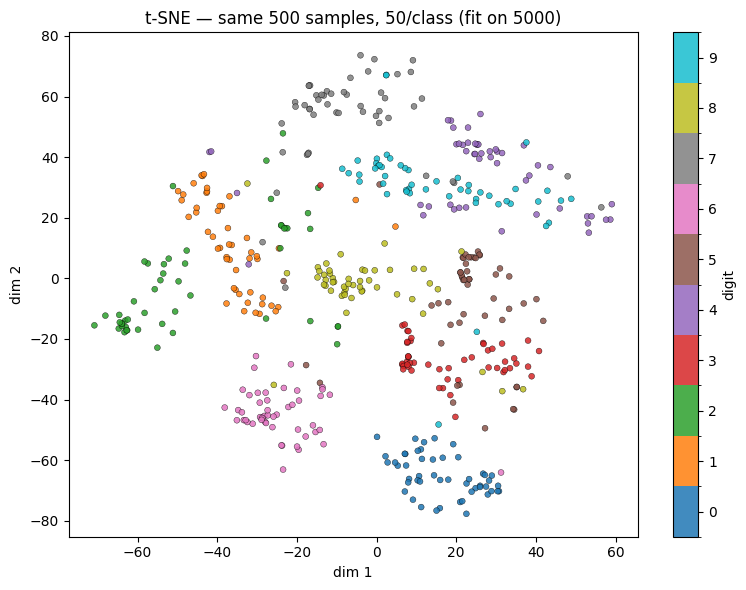

In [2]:
from sklearn.manifold import TSNE

# Fit on all 5000; plot only the same 500 samples (50/class) as other methods
X2 = TSNE(n_components=2, random_state=42, init="random", learning_rate="auto", perplexity=30).fit_transform(X)
pts = X2[sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], c=y[sample_idx], cmap=cmap, norm=norm, s=18, alpha=0.85, edgecolors="k", linewidths=0.3)
plt.colorbar(ticks=range(10), label="digit")
plt.title("t-SNE — same 500 samples, 50/class (fit on 5000)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()

PCA

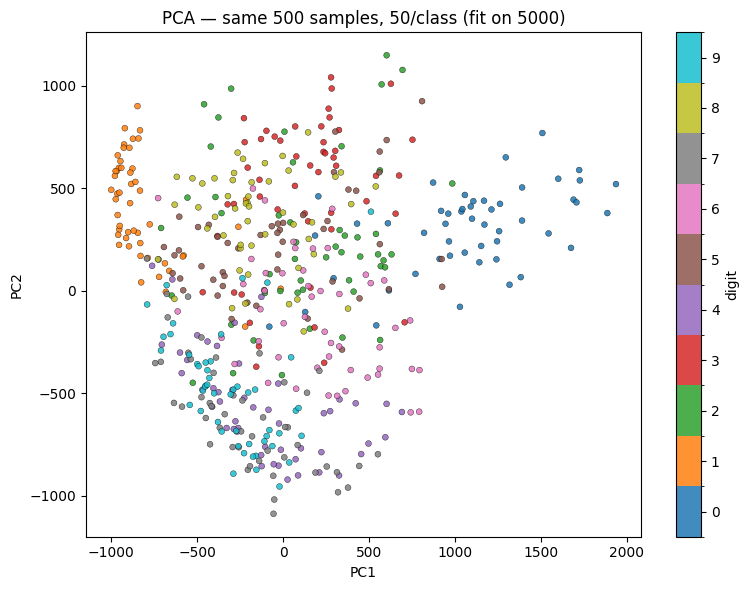

In [3]:
from sklearn.decomposition import PCA

X2 = PCA(n_components=2, random_state=42).fit_transform(X)
pts = X2[sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], c=y[sample_idx], cmap=cmap, norm=norm, s=18, alpha=0.85, edgecolors="k", linewidths=0.3)
plt.colorbar(ticks=range(10), label="digit")
plt.title("PCA — same 500 samples, 50/class (fit on 5000)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

LLE: A nonlinear dimensionality reduction method that preserves local structure using linear relationships

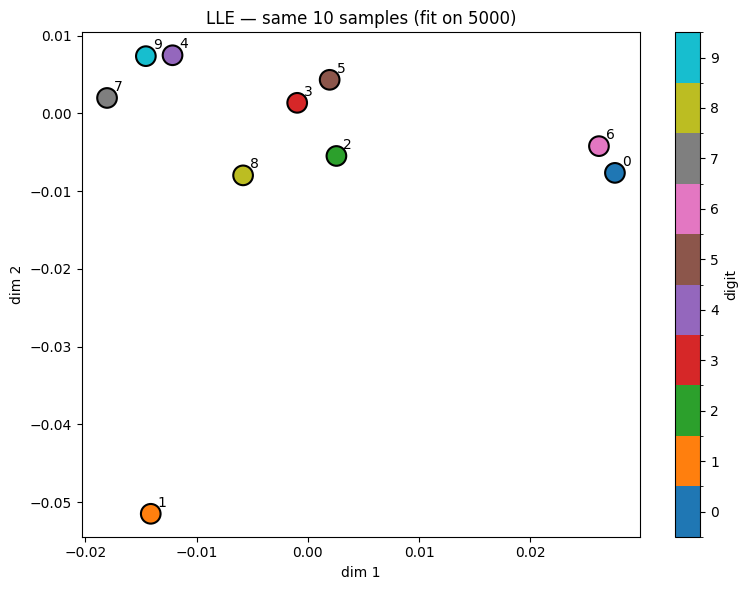

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding

X2 = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42).fit_transform(X)
pts = X2[sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], c=y[sample_idx], cmap=cmap, norm=norm, s=18, alpha=0.85, edgecolors="k", linewidths=0.3)
plt.colorbar(ticks=range(10), label="digit")
plt.title("LLE — same 500 samples, 50/class (fit on 5000)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()

MDS(Multidimensional Scaling): A dimensionality reduction method that tries to preserve distances between all points

/Users/aryamanwade/Desktop/ml_prac/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


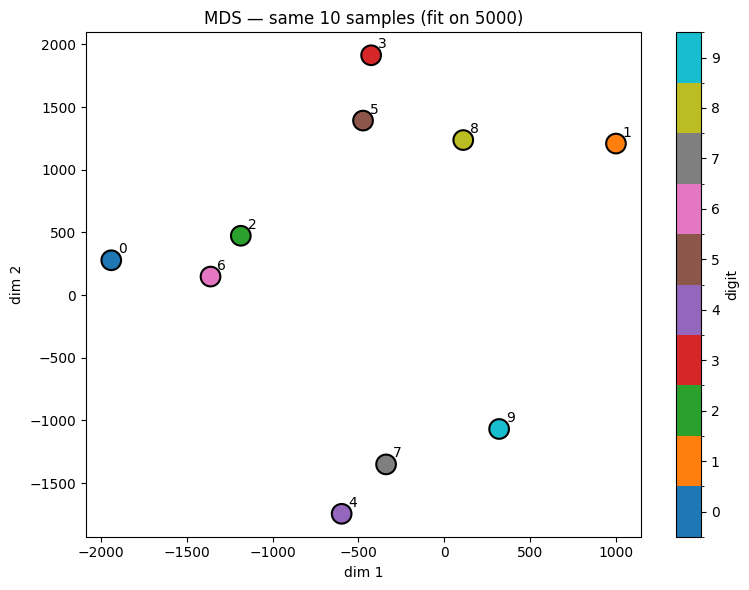

In [ ]:
from sklearn.manifold import MDS

# 5000 points can take a long time; reduce iterations if needed
mds = MDS(
    n_components=2,
    random_state=42,
    normalized_stress="auto",
    max_iter=300,
    n_init=1,
)
X2 = mds.fit_transform(X)
pts = X2[sample_idx]

plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], c=y[sample_idx], cmap=cmap, norm=norm, s=18, alpha=0.85, edgecolors="k", linewidths=0.3)
plt.colorbar(ticks=range(10), label="digit")
plt.title("MDS — same 500 samples, 50/class (fit on 5000)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.tight_layout()
plt.show()